In [1]:
import plt
%load_ext autoreload
%autoreload 2

In [ ]:
from dataset_hasher import hash_datasets

hash_datasets('../Datasets')

In [ ]:
import pandas as pd

df_actors = pd.read_csv('../Datasets/IMDB/actorfilms.csv', low_memory=False)
df_actors = df_actors[pd.to_numeric(df_actors['Year'], errors='coerce') >= 1990]

We took this dataset from IMDB. From this we can see in which films actors were in. We can see the actor's id, movie, the year that movie was released, the ratings and the filmid of the movie.

In [3]:
df_actors

,Actor,ActorID,Film,Year,Votes,Rating,FilmID
39,Lauren Bacall,nm0000002,Ernest & Celestine,2012,18793,7.9,tt1816518
40,Lauren Bacall,nm0000002,The Forger,2012,4472,5.4,tt1368858
41,Lauren Bacall,nm0000002,All at Sea,2010,110,5.7,tt0858500
42,Lauren Bacall,nm0000002,The Walker,2007,5256,5.8,tt0783608
43,Lauren Bacall,nm0000002,Manderlay,2005,22622,7.3,tt0342735
...,...,...,...,...,...,...,...
191868,Roman Griffin Davis,nm9877392,Jojo Rabbit,2019,310904,7.9,tt2584384
191869,Lexi Rabe,nm9962642,Silk Road,2021,2050,5.9,tt7937254
191870,Lexi Rabe,nm9962642,Avengers: Endgame,2019,849079,8.4,tt4154796
191871,Lexi Rabe,nm9962642,Godzilla: King of the Monsters,2019,146737,6.0,tt3741700


In [ ]:
actors_set = sorted(set(df_actors['Actor'].tolist()))  # Sorted for deterministic iteration

In [ ]:
print("We have " +str(len(actors_set)) + " actors in the df_actors dataset.")

We will cut out actors who had their first movies before 1980, because we wanted to work with more up-to-date actors.

In [ ]:
from Artist_Director_Graph.actor_director_functions import cut_off_actors_whose_first_movie_was_before_1980

# cut out actors whose first film was before 1980

actors_after_1980 = cut_off_actors_whose_first_movie_was_before_1980(actors_set, df_actors)

In [ ]:
#We will work with this many actors
print(f"We will only work with {len(actors_after_1980)} actors")

This dataframe contains IMDb ids of movie title's with director ids and writer ids. We will only work with the movies and directors from this df_movie_directors dataset.

In [ ]:
df_movie_directors = pd.read_csv('../Datasets/IMDB/title.crew.tsv', sep='\t', low_memory=False)

In [ ]:
df_movie_directors

This df_name_to_id dataset maps together people ids (e.g. directors, writers, actors) to their names.

In [ ]:
df_name_to_id = pd.read_csv('../Datasets/IMDB/name.basics.tsv', sep='\t', low_memory=False)

In [ ]:
df_name_to_id

We make a graph where actors and directors are nodes and there are directed links between actors to directors if they worked with them. The edge weight indicate how many times.

In [ ]:
from Artist_Director_Graph.actor_director_functions import making_director_actor_graph
import pandas as pd

# Pre-compute lookups dictionary, because dataframes are slow
movie_directors_dict = df_movie_directors.set_index('tconst')['directors'].to_dict()
name_lookup = df_name_to_id.set_index('nconst')['primaryName'].to_dict()

# Filter actors data once and group by actor
actors_filtered = df_actors[df_actors['Actor'].isin(actors_after_1980)]
actors_grouped = actors_filtered.groupby('Actor')

# Initialize graph with all actors at once
actors_director_graph = making_director_actor_graph(actors_after_1980, actors_grouped,movie_directors_dict, name_lookup)

In [ ]:
print(f"The actors-directors graph has {actors_director_graph.number_of_edges()} edges and {actors_director_graph.number_of_nodes()} nodes.")

We take the largest component, so that we will only work with relevant actors who are not separated.

In [ ]:
import networkx as nx
largest_cc_nodes = max(nx.connected_components(actors_director_graph.to_undirected()), key=len)
largest_cc_nodes = sorted(largest_cc_nodes)  # Sort for deterministic graph ordering
actors_director_graph = actors_director_graph.subgraph(largest_cc_nodes)

In [ ]:
print(f"The largest component of the actors-directors graph has {actors_director_graph.number_of_edges()} edges and {actors_director_graph.number_of_nodes()} nodes.")

Here we collect the popular directors. As there are no datasets available with director popularity score, we took the IMDb movies.csv and calculate the popularity by summing the result of multiplying the rating of their movies and the number of rating. We explain the reasons in the report.

In [ ]:
from Artist_Director_Graph.actor_director_functions import get_popular_directors


#We use the IMDb dataset and get rid of movies before 1990
df_movies_imdb = pd.read_csv('../Datasets/IMDb movies.csv', index_col=0, low_memory=False)
df_movies_imdb = df_movies_imdb[pd.to_numeric(df_movies_imdb['year'], errors='coerce') >= 1990]

# Sort by average popularity
director_stats_sorted = get_popular_directors(df_movies_imdb)


We can see that there are indeed popular directors at the beginning of the list

In [ ]:
director_stats_sorted

We check the total_popularity of directors and observe a clear drop around ranks 200–300. Therefore, we select 400 as a slightly higher cutoff to avoid excluding directors who are still meaningfully popular.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
values = director_stats_sorted['total_popularity'].values

plt.plot(values[:int((len(director_stats_sorted)*0.05))])
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Here we performed community detection with the Louvain-algorithm.

In [ ]:
from Artist_Director_Graph.actor_director_functions import make_louvain_communities
import networkx as nx

cluster_labels,nodes, embeddings = make_louvain_communities(actors_director_graph, actors_director_graph)

In [ ]:
from Artist_Director_Graph.cluster_naming_llm import summarize_clusters
from dotenv import load_dotenv
load_dotenv()   #Load the .env file containing the API key for the LLM

names = summarize_clusters(nodes, cluster_labels, cache_path="cluster_names.json")

The next cell is needed for creating a 3D visualization of the graph: https://dh-anna.github.io/Social_Graph_Final_Project/
It only exports the graph in a gziped JSON format that is readable by our visualizer.

In [ ]:
import json
import gzip

# Filter to most important nodes/edges
degree_dict = dict(actors_director_graph.degree())
top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:1000]
subgraph = actors_director_graph.subgraph(top_nodes).copy()

# Create node to cluster mapping from Louvain results
node_to_cluster = {node: int(cluster) for node, cluster in zip(nodes, cluster_labels)}

# Determine node type based on graph structure and add cluster data:
# In this directed graph, edges go from actor -> director
# So: nodes with incoming edges are directors, nodes with only outgoing edges are actors
for node in subgraph.nodes():
    in_degree = subgraph.in_degree(node)
    out_degree = subgraph.out_degree(node)

    if in_degree > 0 and out_degree == 0:
        # Only receives edges = pure director
        subgraph.nodes[node]['type'] = 'director'
    elif in_degree == 0 and out_degree > 0:
        # Only sends edges = pure actor
        subgraph.nodes[node]['type'] = 'actor'
    elif in_degree > 0 and out_degree > 0:
        # Both = actor-director (classify based on which role dominates)
        # If more incoming than outgoing, they're primarily a director
        subgraph.nodes[node]['type'] = 'director' if in_degree >= out_degree else 'actor'
    else:
        # Isolated node (shouldn't happen in largest component)
        subgraph.nodes[node]['type'] = 'unknown'

    # Add cluster data
    if node in node_to_cluster:
        subgraph.nodes[node]['cluster'] = node_to_cluster[node]
    else:
        subgraph.nodes[node]['cluster'] = -1  # Unknown cluster

data = nx.node_link_data(subgraph, edges="links")
with gzip.open('../3d-visualization/public/graph.json.gz', 'wt') as f:
    json.dump(data, f, separators=(',', ':'))


Here we print some of the members from each community.

In [ ]:
from Artist_Director_Graph.actor_director_functions import clusters_to_node, print_members_for_each_clusters

# Create a dictionary mapping cluster to nodes
cluster_to_nodes = clusters_to_node(nodes, cluster_labels)
# Print members of each cluster
print_members_for_each_clusters(cluster_to_nodes)

Here we list some basic statistics about the clusters

We can see that the nodes with the biggest degree centrality are all established directors.

In [ ]:
# Get degree centrality for filtered graph
degree_centrality = nx.degree_centrality(actors_director_graph)
sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True)[:10]

For each cluster whe print out the members who have the highest node centrality.

In [ ]:
from Artist_Director_Graph.actor_director_functions import find_top_n_members_of_each_cluster

# Find top n members by centrality in each cluster, this is just interesting fact
find_top_n_members_of_each_cluster(5, cluster_to_nodes,degree_centrality, actors_director_graph )

Now we analyze which cluster contains directors with the highest node centrality.

In [ ]:
from Artist_Director_Graph.actor_director_functions import calculate_member_centralities, \
    find_cluster_with_highest_avg_centrality

cluster_centralities = calculate_member_centralities(cluster_to_nodes, degree_centrality)

sorted_by_average_centrality = sorted( cluster_centralities.items(), key=lambda x: x[1]['avg_centrality'], reverse=True)

for rank, (cluster_id, data) in enumerate(sorted_by_average_centrality[:10], 1):
    print(f"\n{rank}. Cluster {cluster_id}:")
    print(f"   Avg centrality: {data['avg_centrality']:.6f}")
    print(f"   Size: {data['size']} members")


members_with_centrality = find_cluster_with_highest_avg_centrality(sorted_by_average_centrality, degree_centrality, actors_director_graph)



In [ ]:
from Artist_Director_Graph.actor_director_functions import visualize_actor_director_graph

visualize_actor_director_graph(embeddings,cluster_labels, nodes )

We can also find people in the clusters with this function

In [ ]:
from Artist_Director_Graph.actor_director_functions import find_person_cluster

# Find which cluster contains specific actors/directors

# Example usage
find_person_cluster("Lionel Barrymore", nodes, cluster_labels, cluster_to_nodes)
find_person_cluster("Tom Hanks", nodes, cluster_labels, cluster_to_nodes)

This is needed because we first used another director_popularity dataset, but it turned out to be not so good. After that we created the director_stats_sorted, but by that time we already used the term director_popularity everwhere and we did not want to change it.

In [ ]:
director_popularity = director_stats_sorted

First we wanted to select the first few percentage of the directors as the "most popular directors". We made a cutoff for popular director at 400 as we discussed above.

In [ ]:
from Artist_Director_Graph.actor_director_functions import calculate_popular_directors_for_each_cluster, print_popular_directors_in_each_cluster

# We find the most popular directors
n_popular = 400
popularity_threshold = director_popularity['total_popularity'].nlargest(n_popular).min()  #.quantile(0.75)
popular_directors = set(director_popularity[director_popularity['total_popularity'] >= popularity_threshold]['director'])


print(f"We select the first {len(popular_directors)} directors as popular directors. \n")

# Count popular directors in each cluster
cluster_popular_counts, cluster_popular_directors = calculate_popular_directors_for_each_cluster(cluster_to_nodes,popular_directors)

cluster_popular_directors_percentages= print_popular_directors_in_each_cluster(cluster_popular_counts, cluster_popular_directors, cluster_to_nodes)

In [ ]:
cluster_popular_directors_percentages

In [ ]:
from Artist_Director_Graph.actor_director_functions import check_how_many_popular_directors_in_the_graph

# Check how many popular directors are actually in the graph nodes
check_how_many_popular_directors_in_the_graph(director_popularity, nodes)


With this function we can list the actors in the cluster who worked with the popular directors.

In [ ]:
from Artist_Director_Graph.actor_director_functions import list_actors_who_worked_with_popular_directors_in_cluster
# For each cluster, list actors who worked with popular directors
#list_actors_who_worked_with_popular_directors_in_cluster(cluster_to_nodes, cluster_popular_directors, actors_director_graph)

We have a Celebrity dataset which sort the most popular actors with a popularity sort. We check which cluster contains popular actors and we take the mean popularity of the popular actors.

In [ ]:
from Artist_Director_Graph.actor_director_functions import clusters_by_average_actors_popularity

# Load celebrity data
df_celebrity = pd.read_csv('../Datasets/Celebrity.csv', index_col=0)

actor_popularity_map, cluster_avg_popularity, cluster_number_of_popular_actors = clusters_by_average_actors_popularity(df_celebrity, cluster_to_nodes)

Here we list the clusters with the highest degree centrality, the clusters where the percentage of directors who are popular are the higest, and the clusters where the average popularity of popular directors in the cluster are the highest. We can see that the clusters with the highest node centrality and, clusters with the highest director popularity percentage are really overlapping. This is not the case with the average popularity in the cluster, but this is also due to the fact that the average popularity of directors are not spread out that much, ranging only from approximately 30 to 59 from the lowest to the highest.

In [ ]:
from Artist_Director_Graph.actor_director_functions import show_clusters_centrality_vs_popularity_table

show_clusters_centrality_vs_popularity_table([lst[0] for lst in sorted_by_average_centrality],sorted(cluster_popular_directors_percentages, key=cluster_popular_directors_percentages.get, reverse=True),sorted(cluster_avg_popularity, key=cluster_avg_popularity.get, reverse=True), 10 )

Sentiment analysis on movie's descriptions.

In [ ]:
word_scores = {}
with open("labMIT-1.0.txt", 'r', encoding='utf-8') as f:
            next(f)
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) >= 3:
                    word = parts[0].lower()
                    happiness_score = float(parts[2])
                    word_scores[word] = happiness_score

In [ ]:
import nltk

nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

## Movies in Each Cluster

Now let's iterate through each cluster and collect all the movies associated with directors in those clusters.

In [ ]:
from Artist_Director_Graph.cluster_movies_analysis import (
    collect_cluster_movies,
    get_unique_movies_per_cluster,
    print_cluster_movies_summary,
    print_cluster_movies_detail,
)

# Collect all movies for each cluster
cluster_movies = collect_cluster_movies(
    cluster_to_nodes=cluster_to_nodes,
    df_actors=df_actors,
    movie_directors_dict=movie_directors_dict,
    name_lookup=name_lookup
)

# Get unique movies (not actor-movie pairs)
cluster_unique_movies = get_unique_movies_per_cluster(cluster_movies)

# Print summary
summary = print_cluster_movies_summary(cluster_unique_movies, cluster_to_nodes, top_clusters=20)

In [ ]:
cluster_movies[28]

In [ ]:
len(cluster_unique_movies)

In [ ]:
duck

In [ ]:
'''
from Artist_Director_Graph.sentiment_analysis import calculate_sentiment_labmit

sentiment_scores_of_clusters = {}
movies_sentiment ={}
sentiment_scores_of_genres_in_clusters = {}

for cluster in cluster_unique_movies:
    genre_count = {}
    cluster_sentiment_score = 0
    sentiment_scores_of_genres_in_clusters[cluster] = {}
    for movie in cluster_movies[cluster]:
        film_id = movie['film_id']
        description = str(df_movies_imdb[df_movies_imdb.index == film_id]['description'])
        movies_sentiment[movie['film_id']] ={}

        sentiment = calculate_sentiment_labmit(description, word_scores)['labmit_mean']
        matching_rows = df_movies_imdb[df_movies_imdb.index == film_id]
        if not matching_rows.empty:
            movies_sentiment[film_id]['genres'] = df_movies_imdb[df_movies_imdb.index == film_id]['genre'].values[0].split(', ')
            movies_sentiment[film_id]['sentiment'] = sentiment
        cluster_sentiment_score += sentiment


        if len(matching_rows) > 0:
            for i in range(len(movies_sentiment[film_id]['genres'])):
                genre = movies_sentiment[film_id]['genres'][i]
                if genre not in sentiment_scores_of_genres_in_clusters[cluster]:
                    sentiment_scores_of_genres_in_clusters[cluster][genre] = 0
                sentiment_scores_of_genres_in_clusters[cluster][genre]+= movies_sentiment[film_id]['sentiment']
                if not genre in genre_count:
                    genre_count[genre] = 0
                genre_count[genre] +=1
    for key in sentiment_scores_of_genres_in_clusters[cluster]:
        sentiment_scores_of_genres_in_clusters[cluster][key] /= genre_count[key]

    if len(cluster_movies[cluster]) != 0:
        sentiment_scores_of_clusters[cluster] = cluster_sentiment_score / len(cluster_movies[cluster])
    else:
        sentiment_scores_of_clusters[cluster] = 0

for key, value in sentiment_scores_of_clusters.items():
    print(f"The sentiment of cluster {key} is {value}.")

'''

We save the sentiment scores into files, because calculating them takes nearly 15 minutes.

In [ ]:
'''
import json
sentiment_scores_of_clusters= {int(k): v for k, v in sentiment_scores_of_clusters.items()}
with open("sentiment_scores_of_clusters.json", "w") as f:
    json.dump(sentiment_scores_of_clusters, f, indent=4)

sentiment_scores_of_genres_in_clusters= {int(k): v for k, v in sentiment_scores_of_genres_in_clusters.items()}
with open("sentiment_scores_of_genres_in_clusters.json", "w") as f:
    json.dump(sentiment_scores_of_genres_in_clusters, f, indent=4)


'''

In [ ]:
import json
with open("sentiment_scores_of_clusters.json", "r") as f:
    sentiment_scores_of_clusters = json.load(f)

with open("sentiment_scores_of_genres_in_clusters.json", "r") as f:
    sentiment_scores_of_genres_in_clusters = json.load(f)

Here we have the average sentiment of each clusters.

In [ ]:
for key, value in sentiment_scores_of_clusters.items():
    print(f"The sentiment of cluster {key} is {value}.")

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
keys = list(sentiment_scores_of_clusters.keys())
values = list(sentiment_scores_of_clusters.values())

outlier_clusters = {k: v for k, v in sentiment_scores_of_clusters.items() if v < 4}
main_clusters = {k: v for k, v in sentiment_scores_of_clusters.items() if v >= 4}

main_keys = list(main_clusters.keys())
main_values = list(main_clusters.values())

fig, ax = plt.subplots(figsize=(14, 8))


colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(main_keys)))


bars = ax.bar(main_keys, main_values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylim(5.0, 5.7)


for bar, val in zip(bars, main_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

mean_val = np.mean(main_values)
ax.axhline(y=mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')

ax.set_xlabel('Community ID', fontsize=14)
ax.set_ylabel('Sentiment Score', fontsize=14)
ax.set_title('Average Sentiment Score of Communities using LabMT\n(Zoomed View: 5.0-5.7 Range)',
             fontsize=14, fontweight='bold')

ax.set_xticks(main_keys)
ax.tick_params(axis='both', labelsize=10)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)


ax.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.savefig('sentiment_scores_by_communities_using_labmit.png', dpi=300, bbox_inches='tight')
plt.show()


WWe did a sentiment analysis with a Hugging Face pipeline, using the "sentiment-analysis" model. (https://huggingface.co/blog/sentiment-analysis-python) This models runs for nearly one and a half hour so we saved the outcome to the llm_sentiment_scores_of_clusters.npy.

In [105]:
'''
from tqdm.auto import tqdm
from Artist_Director_Graph.sentiment_analysis import calculate_sentiment

llm_sentiment_scores_of_clusters = {}

for cluster in tqdm(cluster_unique_movies):
    # Collect all descriptions for this cluster
    descriptions = []
    for movie in cluster_movies[cluster]:
        description = str(df_movies_imdb[df_movies_imdb.index == movie['film_id']]['description'].values)
        if description and description != 'nan':
            descriptions.append(description)

    # Batch process all descriptions at once
    if descriptions:
        sentiment_results = calculate_sentiment(descriptions, batch_size=32)


        sentiment_scores = []
        for result in sentiment_results:
            if result:
                if result['label'] == 'POSITIVE':
                    sentiment_scores.append(result['score'])
                else:  # NEGATIVE
                    sentiment_scores.append(1 - result['score'])

        # Calculate average sentiment for the cluster
        if sentiment_scores:
            llm_sentiment_scores_of_clusters[cluster] = sum(sentiment_scores) / len(sentiment_scores)
        else:
            llm_sentiment_scores_of_clusters[cluster] = 0.5  # neutral default
    else:
        llm_sentiment_scores_of_clusters[cluster] = 0.5  # neutral default
'''

"\nfrom tqdm.auto import tqdm\nfrom Artist_Director_Graph.sentiment_analysis import calculate_sentiment\n\nllm_sentiment_scores_of_clusters = {}\n\nfor cluster in tqdm(cluster_unique_movies):\n    # Collect all descriptions for this cluster\n    descriptions = []\n    for movie in cluster_movies[cluster]:\n        description = str(df_movies_imdb[df_movies_imdb.index == movie['film_id']]['description'].values)\n        if description and description != 'nan':\n            descriptions.append(description)\n\n    # Batch process all descriptions at once\n    if descriptions:\n        sentiment_results = calculate_sentiment(descriptions, batch_size=32)\n\n\n        sentiment_scores = []\n        for result in sentiment_results:\n            if result:\n                if result['label'] == 'POSITIVE':\n                    sentiment_scores.append(result['score'])\n                else:  # NEGATIVE\n                    sentiment_scores.append(1 - result['score'])\n\n        # Calculate aver

Here we load the precomputed llm sentiment scores from the of_clusters from the llm_sentiment_scores_of_clusters.npy file.

In [195]:
#np.save("llm_sentiment_scores_of_clusters", llm_sentiment_scores_of_clusters)
_llm_sentiment_scores_of_clusters = np.load("llm_sentiment_scores_of_clusters.npy", allow_pickle=True).item()
print(_llm_sentiment_scores_of_clusters)

{0: 0.49884087357409157, 1: 0.6256001282718563, 2: 0.0012641549110412598, 3: 0.5415876712787356, 4: 0.42303328770251314, 5: 0.5896448723985928, 6: 0.840635135769844, 7: 0.610425024712801, 8: 0.5329450638063492, 9: 0.6410132329743188, 10: 0.39829768737157184, 11: 0.5422851474760956, 12: 0.6575550651005484, 13: 0.16385726506016643, 14: 0.686577320098877, 15: 0.6322006583213806, 16: 0.6134870300690333, 17: 0.6334950675000001, 18: 0.5916924473563748, 19: 0.5826734955802735, 20: 0.6226212937088227, 21: 0.6317983905134885, 22: 0.583894481598587, 23: 0.704132382247759, 24: 0.6671978970053335, 25: 0.9631664355595907, 26: 0.9710230032602946, 27: 0.5427695678586071, 28: 0.9991794705390931}


This is the barchart of the sentiment of each clusters using Hugging Face's pipeline. A sentiment is if it is close to 1 and negative if it is close to 0.

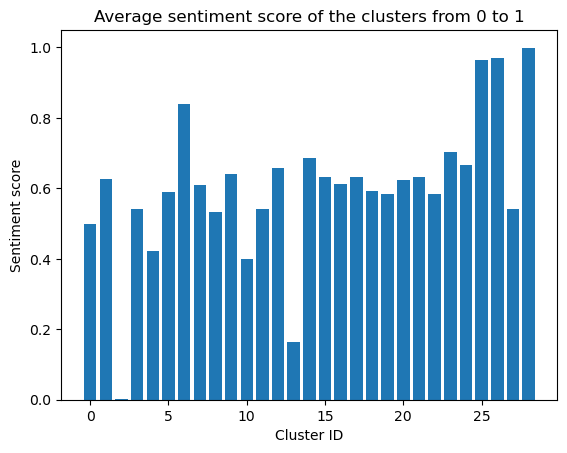

In [196]:
from matplotlib import pyplot as plt

# Extract keys and values from the dictionary
keys = list(_llm_sentiment_scores_of_clusters.keys())
values = list(_llm_sentiment_scores_of_clusters.values())

# Create the bar chart
plt.bar(keys, values)
plt.xlabel('Cluster ID')
plt.ylabel('Sentiment score')
plt.title('Average sentiment score of the clusters from 0 to 1')
plt.savefig('sentiment_scores_by_clusters_using_hugging_face.png', dpi=300, bbox_inches='tight')
plt.show()

## Analyze the clusters by genre and production companies
Genre distribution across different clusters.

In [197]:
from Artist_Director_Graph.cluster_attribute_analysis import (
    map_movies_to_attributes,
    analyze_attribute_distribution,
    get_specialization_score,
    compare_clusters_by_attribute,
    visualize_top_attributes_by_cluster,
    print_specialization_ranking,
    create_attribute_heatmap
)

# Map movies to genres
cluster_genres = map_movies_to_attributes(cluster_movies, df_movies_imdb, analysis_type='genre')

print(f"\nWe found genres for {len(cluster_genres)} clusters")


We found genres for 35 clusters


In [198]:
# Analyze genre distribution for each cluster
cluster_genre_stats = analyze_attribute_distribution(
    cluster_genres,
    cluster_to_nodes,
    analysis_type='genre',
    top_n=10
)

Genre analysis by cluster

Cluster 0 (5725 movies)
  Total movies which have genres information: 46891
  From this, there was  22 number of genres:
  Top 10 genres:
     1. Drama                                9412 ( 20.1%)
     2. Action                               6102 ( 13.0%)
     3. Comedy                               6020 ( 12.8%)
     4. Thriller                             5959 ( 12.7%)
     5. Crime                                4162 (  8.9%)
     6. Horror                               3852 (  8.2%)
     7. Romance                              2130 (  4.5%)
     8. Adventure                            1912 (  4.1%)
     9. Mystery                              1711 (  3.6%)
    10. Sci-Fi                               1612 (  3.4%)

Cluster 1 (3557 movies)
  Total movies which have genres information: 33356
  From this, there was  20 number of genres:
  Top 10 genres:
     1. Drama                                8735 ( 26.2%)
     2. Comedy                               44

high diversity score means the cluster works across many genres, while a low score indicates specialization in fewer genres.

Visualizations to better understand the genre patterns across clusters.


Visualization saved as 'cluster_genre_distribution.png'


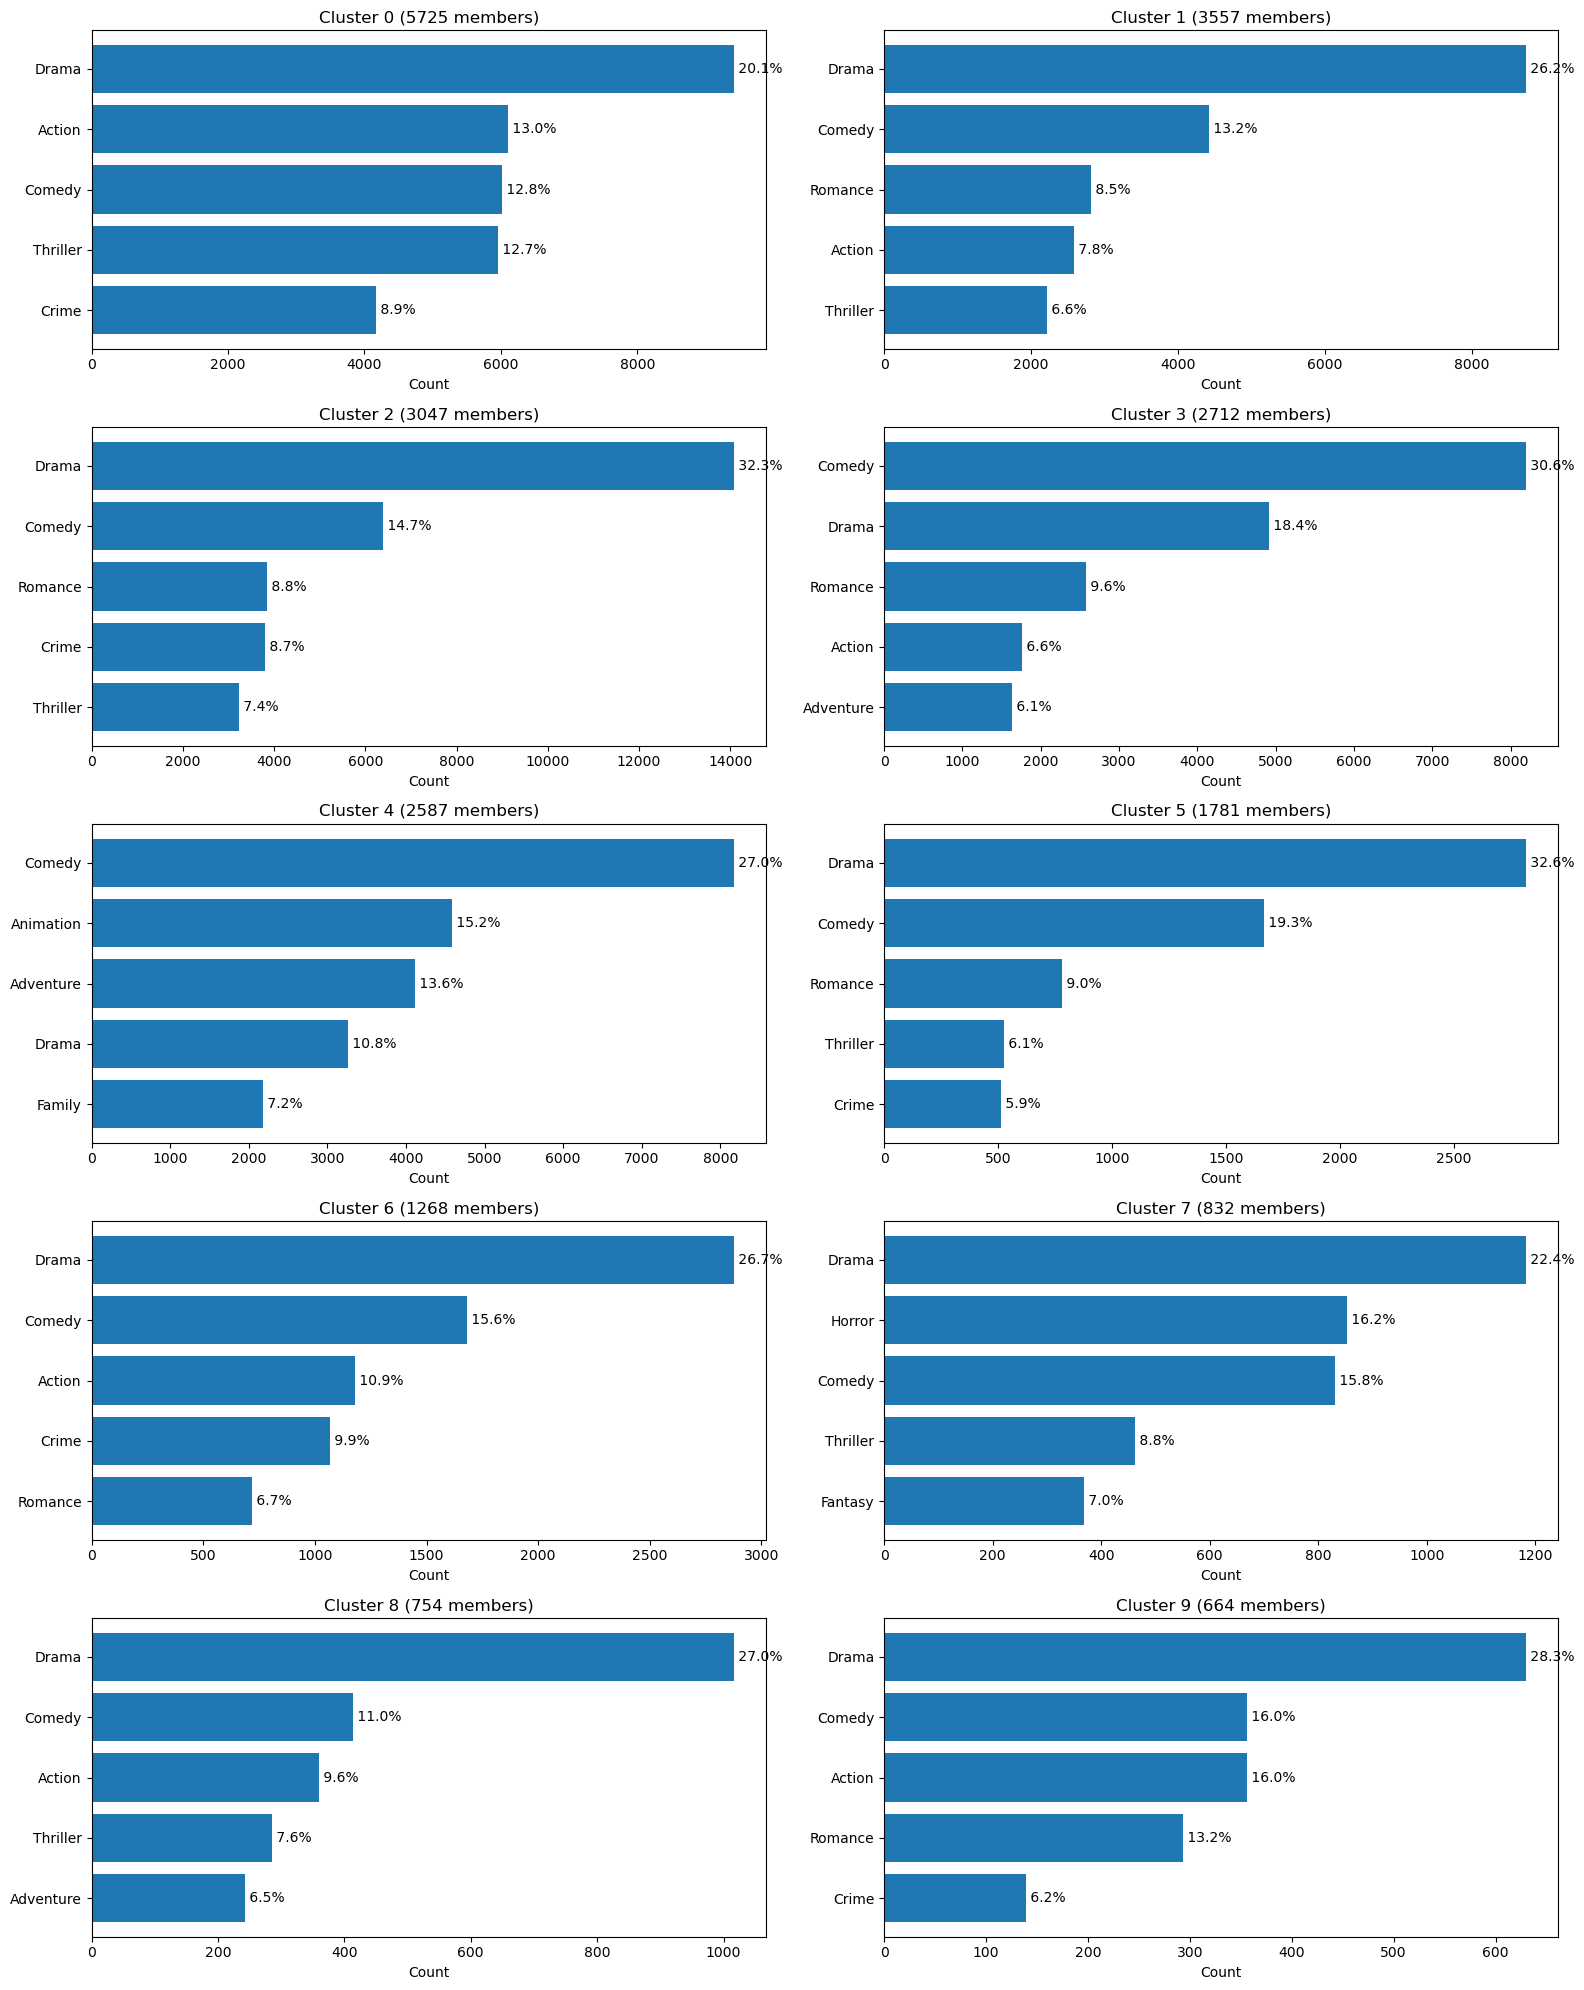

In [199]:
# Visualize top genres for the largest clusters
fig_genres = visualize_top_attributes_by_cluster(cluster_genre_stats, analysis_type='genre', top_clusters=len(cluster_movies), top_items=5)

Genre Specialization ranking

Most Specialized (focused on fewer genres):
 1. Cluster 29: Diversity=0.000, Unique=1, Total mentions=2
      → Top genres: Drama (100.0%)
 2. Cluster 33: Diversity=0.000, Unique=1, Total mentions=2
      → Top genres: Biography (100.0%)
 3. Cluster 34: Diversity=0.000, Unique=1, Total mentions=2
      → Top genres: Comedy (100.0%)
 4. Cluster 19: Diversity=0.518, Unique=11, Total mentions=264
      → Top genres: Comedy (43.9%), Drama (42.8%), Crime (3.8%)
 5. Cluster 17: Diversity=0.612, Unique=15, Total mentions=668
      → Top genres: Comedy (31.3%), Action (28.4%), Animation (26.3%)
 6. Cluster 24: Diversity=0.725, Unique=3, Total mentions=7
      → Top genres: Comedy (71.4%), Horror (14.3%), Family (14.3%)
 7. Cluster 12: Diversity=0.726, Unique=19, Total mentions=2226
      → Top genres: Drama (27.9%), Comedy (19.9%), Romance (15.0%)
 8. Cluster 10: Diversity=0.731, Unique=20, Total mentions=2248
      → Top genres: Drama (31.6%), Comedy (20.3%), Rom

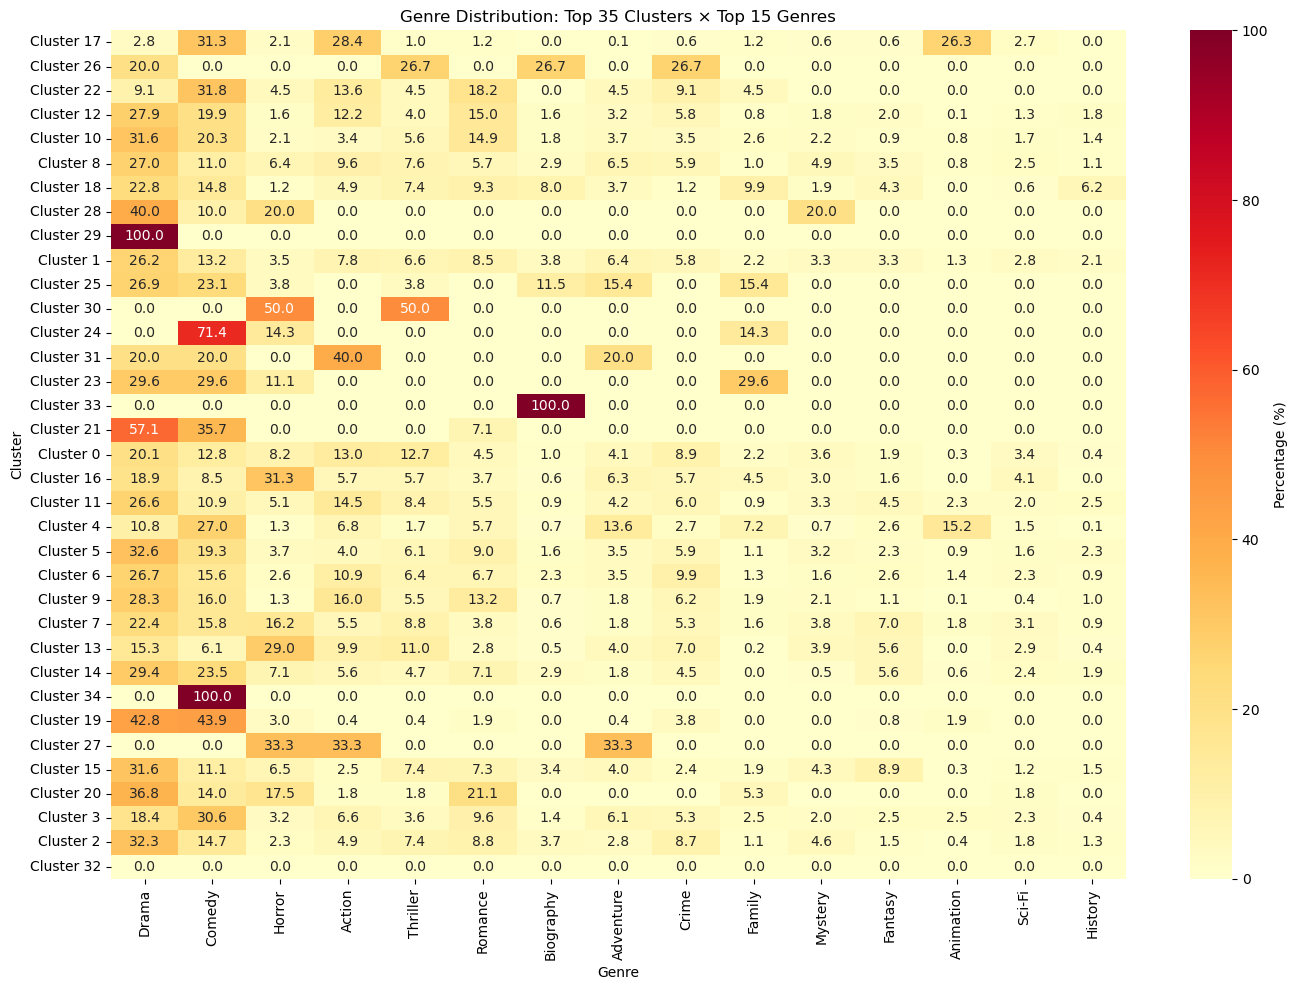

In [200]:
# Calculate genre specialization scores and create heatmap
genre_specialization_scores = get_specialization_score(cluster_genres)
print_specialization_ranking(genre_specialization_scores, cluster_genres, analysis_type='genre', show_top_n=3)

# Create genre comparison matrix and heatmap
genre_matrix = compare_clusters_by_attribute(cluster_genres)
df_genre_heatmap = create_attribute_heatmap(genre_matrix, analysis_type='genre', top_n_clusters=len(cluster_movies), top_n_items=15)

In [112]:
# Production Company Analysis
# Map movies to production companies
print("Mapping cluster movies to production companies...")
cluster_companies = map_movies_to_attributes(cluster_movies, df_movies_imdb, analysis_type='production_company')

print(f"\nMapped production companies for {len(cluster_companies)} clusters")

# Analyze production company distribution for each cluster
cluster_company_stats = analyze_attribute_distribution(
    cluster_companies,
    cluster_to_nodes,
    analysis_type='production_company',
    top_n=10
)

Mapping cluster movies to production companies...

Mapped production companies for 35 clusters
Production Company analysis by cluster

Cluster 0 (5725 movies)
  Total movies which have production companies information: 20119
  From this, there was  2927 number of production companies:
  Top 10 production companies:
     1. Dimension Films                       315 (  1.6%)
     2. Columbia Pictures                     278 (  1.4%)
     3. New Line Cinema                       261 (  1.3%)
     4. Twentieth Century Fox                 215 (  1.1%)
     5. Epic Pictures Group                   208 (  1.0%)
     6. Millennium Films                      172 (  0.9%)
     7. Warner Bros.                          171 (  0.8%)
     8. Paramount Pictures                    170 (  0.8%)
     9. Universal Pictures                    157 (  0.8%)
    10. Miramax                               153 (  0.8%)

Cluster 1 (3557 movies)
  Total movies which have production companies information: 13679
  

Visualizations to better understand the production company patterns across clusters.


Visualization saved as 'cluster_production_company_distribution.png'
Production Company Specialization ranking

Most Specialized (focused on fewer production companies):
 1. Cluster 23: Diversity=0.000, Unique=1, Total mentions=8
      → Top production companies: Wonderland Sound and Vision (100.0%)
 2. Cluster 27: Diversity=0.000, Unique=1, Total mentions=1
      → Top production companies: Automatik Entertainment (100.0%)
 3. Cluster 30: Diversity=0.000, Unique=1, Total mentions=1
      → Top production companies: The Asylum (100.0%)
 4. Cluster 33: Diversity=0.000, Unique=1, Total mentions=2
      → Top production companies: Fulwell 73 (100.0%)
 5. Cluster 34: Diversity=0.000, Unique=1, Total mentions=2
      → Top production companies: Teahm Beahm (100.0%)
 6. Cluster 17: Diversity=0.441, Unique=23, Total mentions=243
      → Top production companies: A Bunch of Filmmakers (72.4%), Rooster Teeth Productions (4.5%), Talmarc Film Productions (2.1%)
 7. Cluster 19: Diversity=0.457, U

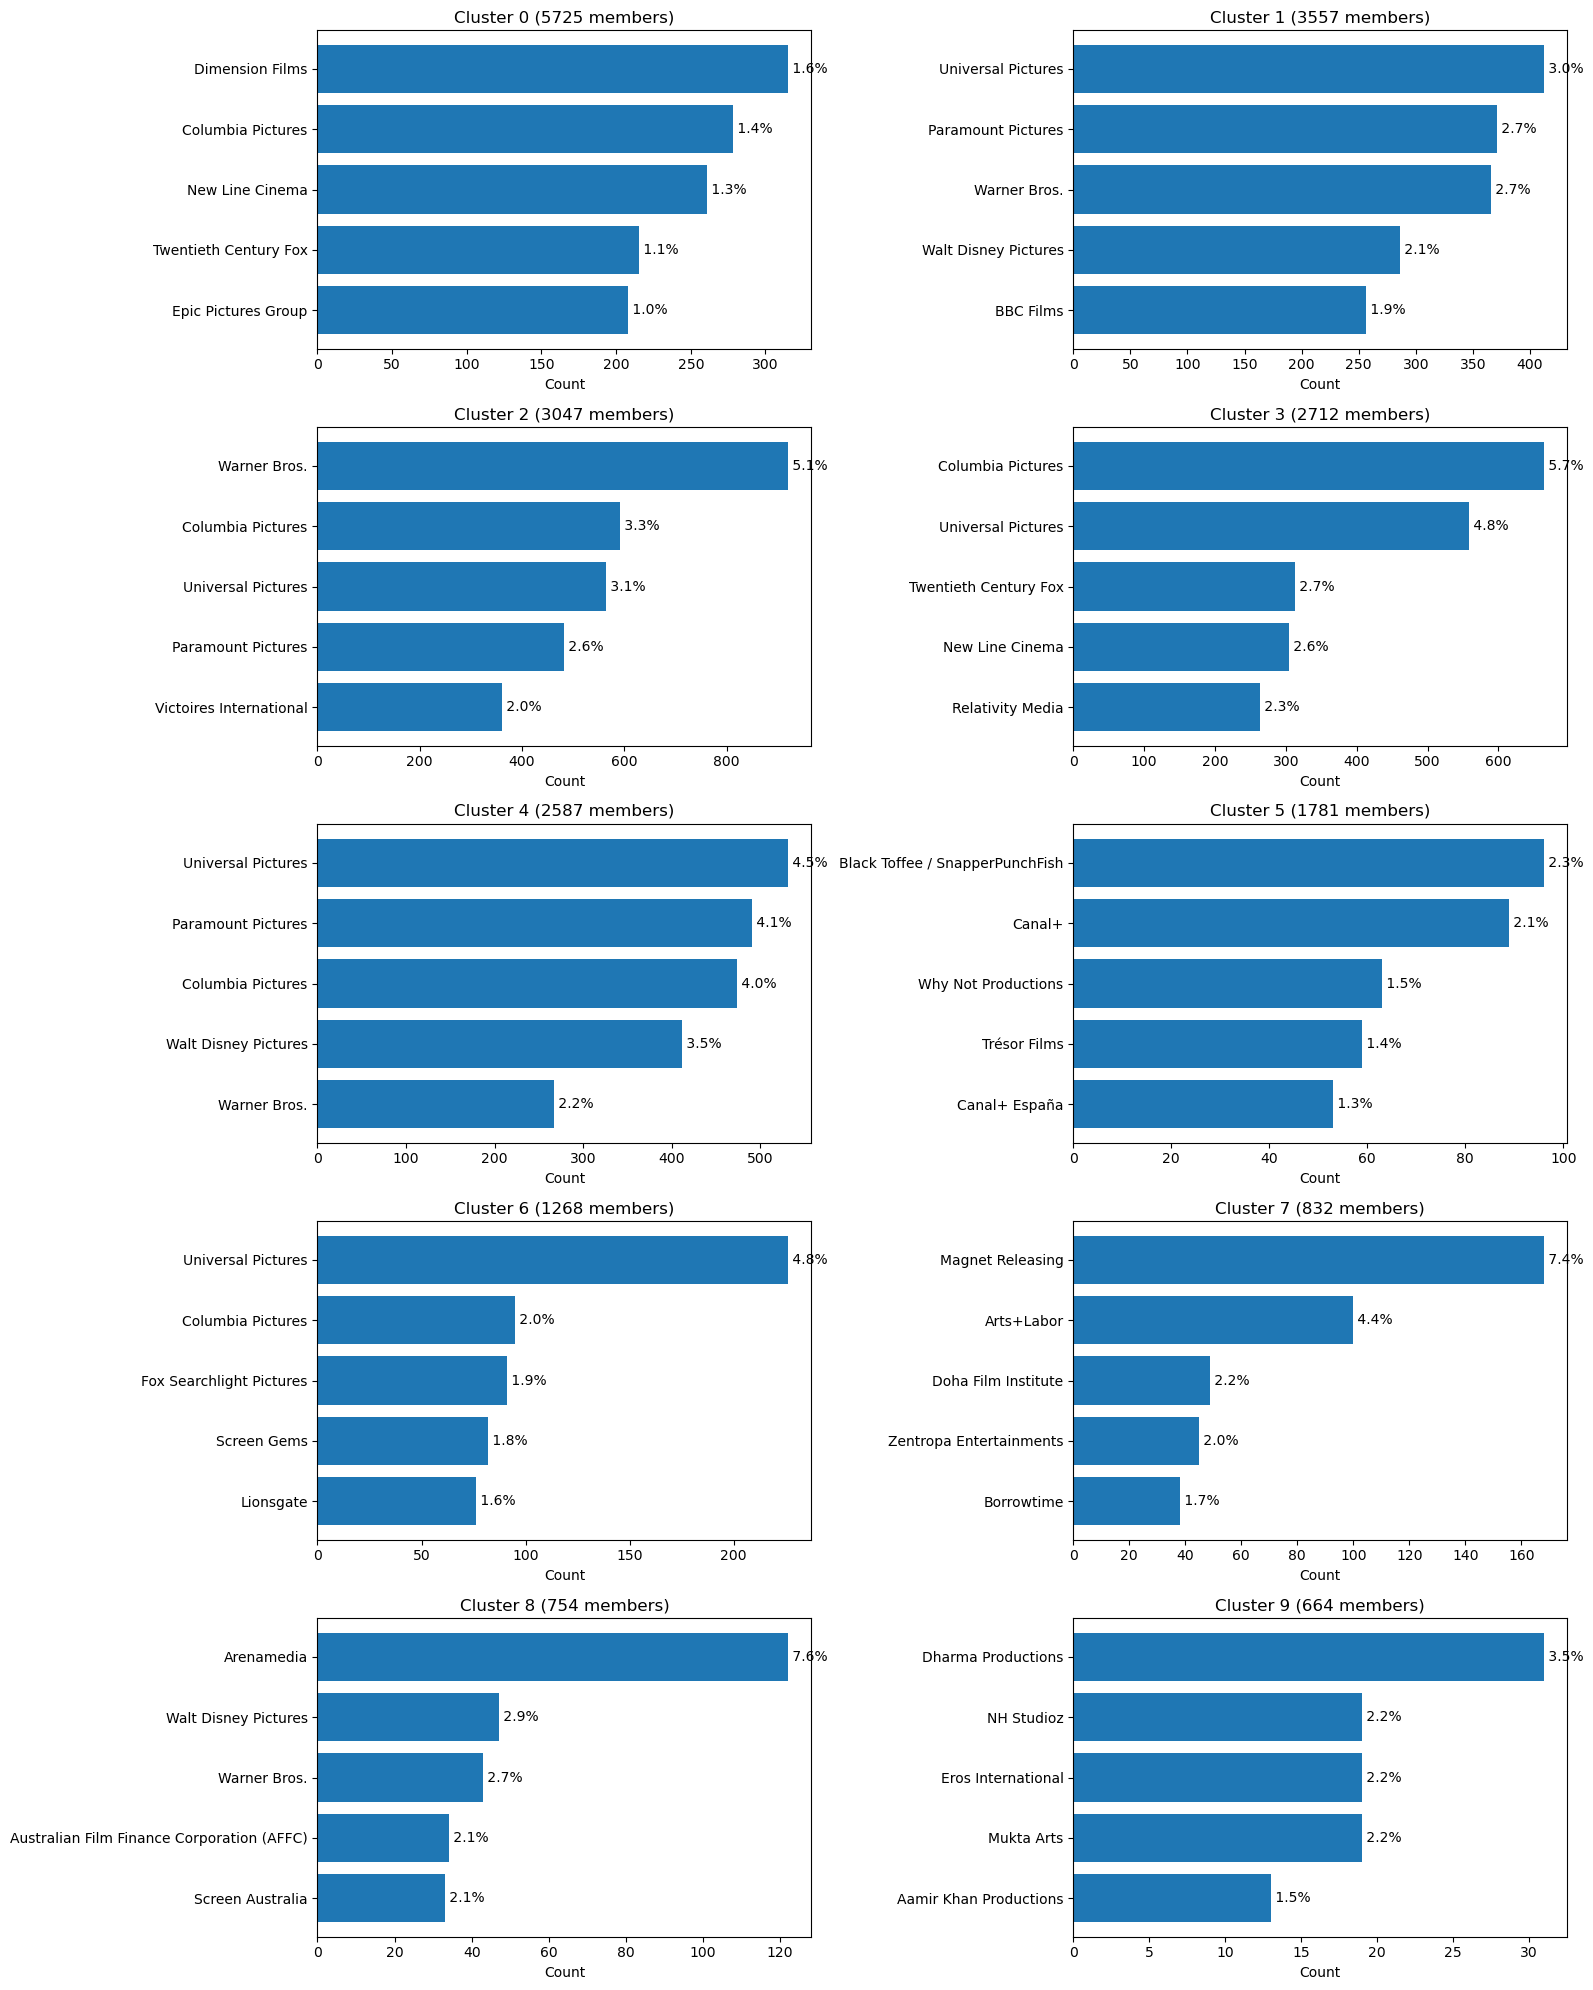

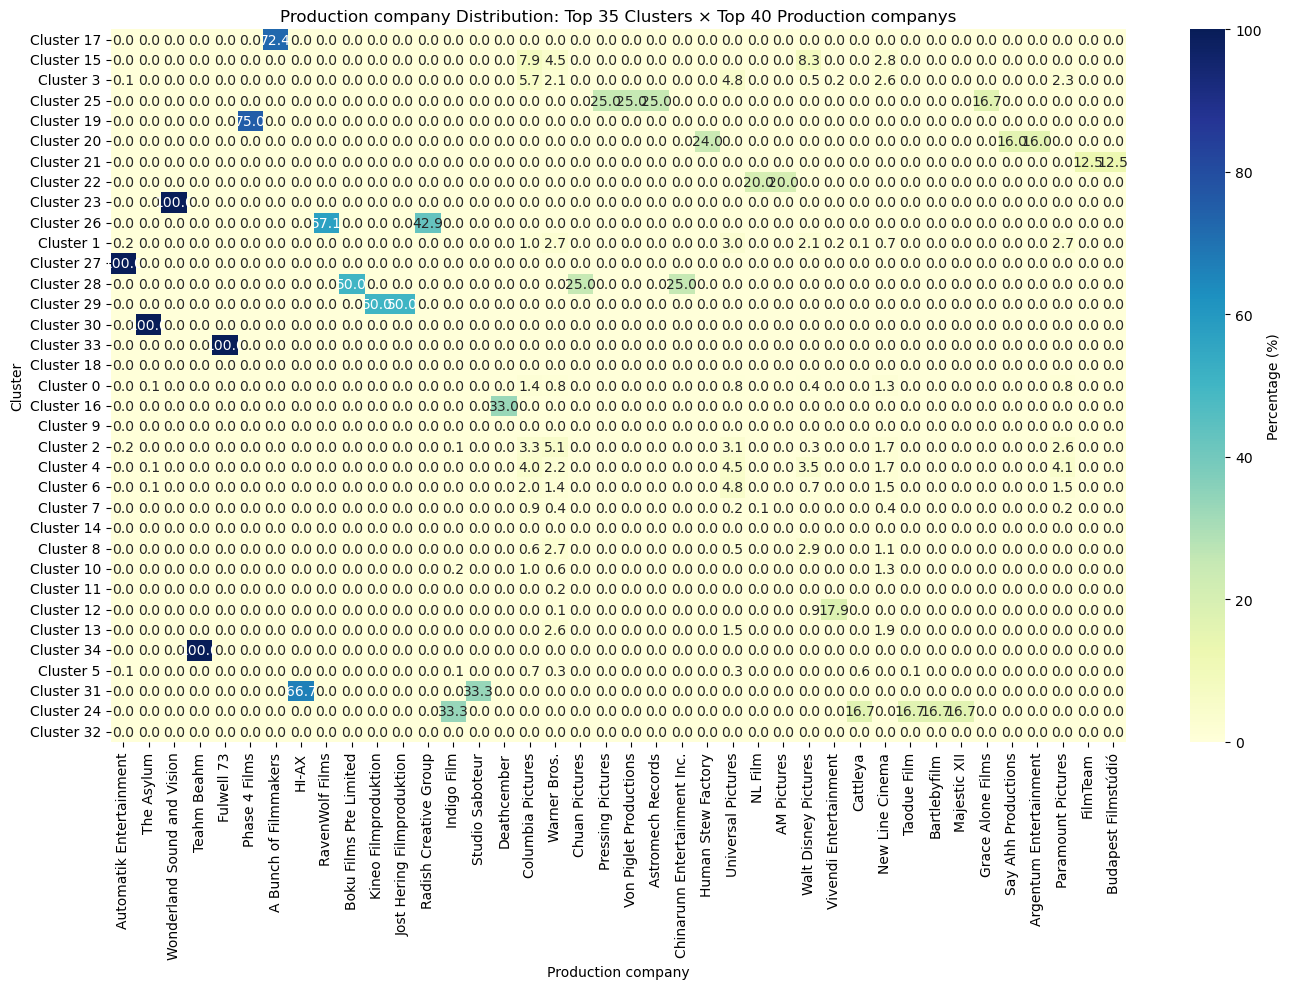

In [113]:
# Visualize top production companies for the largest clusters
fig_companies = visualize_top_attributes_by_cluster(cluster_company_stats, analysis_type='production_company', top_clusters=10, top_items=5)

# Calculate production company specialization scores and create heatmap
company_specialization_scores = get_specialization_score(cluster_companies)
print_specialization_ranking(company_specialization_scores, cluster_companies, analysis_type='production_company', show_top_n=3)

# Create production company comparison matrix and heatmap
company_matrix = compare_clusters_by_attribute(cluster_companies)
df_company_heatmap = create_attribute_heatmap(company_matrix, analysis_type='production_company', top_n_clusters=len(cluster_movies), top_n_items=40)

Time Era analysis

In [114]:
from Artist_Director_Graph.cluster_time_period_analysis import (
    analyze_cluster_time_periods,
    categorize_by_era,
    print_time_period_summary,
    find_era_specialized_clusters,
    visualize_era_distribution,
    create_timeline_heatmap
)

In [115]:
# Analyze time period statistics for each cluster
df_time_stats = analyze_cluster_time_periods(cluster_unique_movies, cluster_to_nodes)

# Categorize movies by era (Classic, Golden Age, Modern, Contemporary)
df_era = categorize_by_era(cluster_unique_movies, cluster_to_nodes)

In [116]:
# Print comprehensive time period summary
print_time_period_summary(df_time_stats, df_era, top_n=20)

TIme period analysis by cluster:

Cluster  Movies   Members  Year Range      Mean Year    Median   Dominant Era   
----------------------------------------------------------------------------------------------------
0        4603     5725     1990-2021       2007.0       2008     Modern         
1        2738     3557     1990-2021       2008.2       2010     Modern         
2        2630     3047     1990-2021       2007.4       2009     Modern         
5        2255     1781     1990-2021       2008.2       2009     Modern         
4        1624     2587     1990-2021       2006.1       2007     Modern         
3        1507     2712     1990-2021       2011.9       2013     Modern         
6        837      1268     1990-2021       2009.4       2011     Modern         
7        808      832      1990-2021       2010.0       2011     Modern         
9        707      664      1990-2021       2009.0       2010     Modern         
10       518      556      1990-2021       2010.1      

In [117]:
# Find clusters that are specialized in specific eras (>60% of movies in one era)
specialized_clusters = find_era_specialized_clusters(df_era, threshold=60)

Clusters specialized in specific eras(>60% in one era)

Cluster    Era                            Movies          Percentage  
----------------------------------------------------------------------
29         Contemporary (2016-2021)       3/3          100.0       %
30         Contemporary (2016-2021)       1/1          100.0       %
31         Contemporary (2016-2021)       2/2          100.0       %
33         Contemporary (2016-2021)       2/2          100.0       %
34         Modern (2008-2016)             1/1          100.0       %
25         Modern (2008-2016)             4/6          66.7        %



Visualization saved as 'cluster_era_distribution.png'


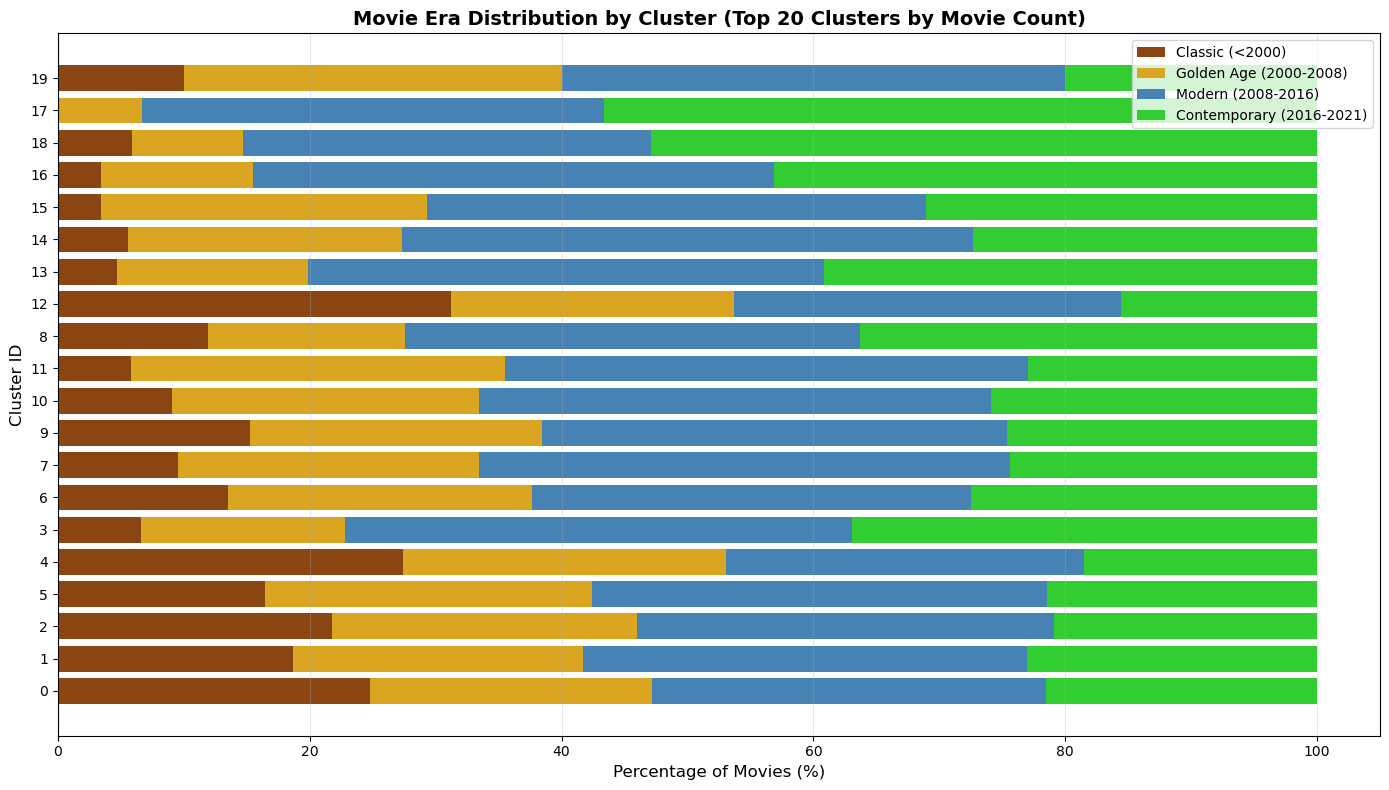

In [118]:
# Create era distribution visualization (stacked bar chart)
fig_era = visualize_era_distribution(df_era, output_file='cluster_era_distribution.png', top_n=20)

Timeline heatmap saved as 'cluster_timeline_heatmap.png'


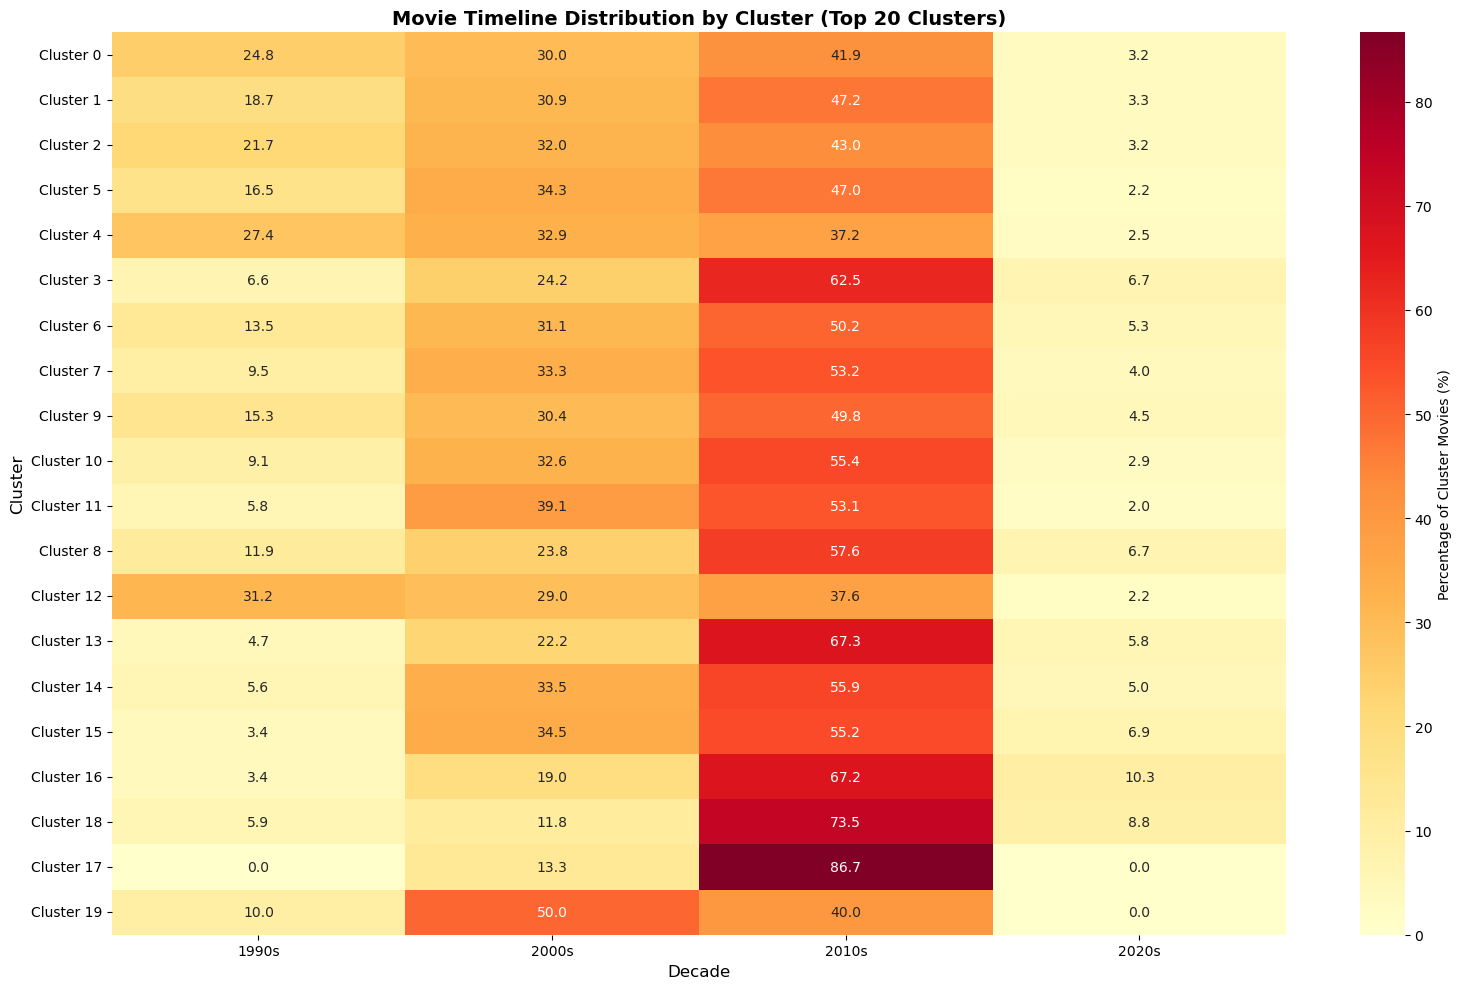

In [119]:
# Create timeline heatmap showing movie distribution by decade
fig_timeline = create_timeline_heatmap(cluster_unique_movies, output_file='cluster_timeline_heatmap.png', top_n=20)

## Sentiment Analysis on Movies of Popular Actors

In this section, we analyze the sentiment of movie descriptions for films featuring popular actors from the Celebrity.csv dataset. We try to find out whether popular actors has a specific sentiment of movies

In [120]:

# Load celebrity data if not already loaded
if 'df_celebrity' not in globals():
    df_celebrity = pd.read_csv('../Datasets/Celebrity.csv', index_col=0)

# Load IMDb movies data if not already loaded  
if 'df_movies_imdb' not in globals():
    df_movies_imdb = pd.read_csv('../Datasets/IMDb movies.csv', index_col=0, low_memory=False)

# Load actor films data if not already loaded
if 'df_actors' not in globals():
    df_actors = pd.read_csv('../Datasets/IMDB/actorfilms.csv', low_memory=False)
    df_actors = df_actors[pd.to_numeric(df_actors['Year'], errors='coerce') >= 1990]

In [121]:
# Select top celebrities for analysis (top 50 by popularity)
top_celebrities = df_celebrity.nlargest(500, 'popularity')
print(f"Analyzing top {len(top_celebrities)} celebrities by popularity")

celebrity_names = top_celebrities['name'].tolist()
actor_movies = df_actors[df_actors['Actor'].isin(celebrity_names)].copy()

print(f"Found {len(actor_movies)} movie entries for top celebrities")


df_movies_imdb_clean = df_movies_imdb[['title', 'description', 'avg_vote', 'year']].copy()
df_movies_imdb_clean = df_movies_imdb_clean.dropna(subset=['description'])

# Merge actor movies with movie descriptions
actor_movies_with_desc = actor_movies.merge(
    df_movies_imdb_clean,
    left_on='Film',
    right_on='title',
    how='inner'
)

print(f"Matched {len(actor_movies_with_desc)} movies with descriptions")
print(f"Unique movies: {actor_movies_with_desc['Film'].nunique()}")
actor_movies_with_desc.head()

Analyzing top 500 celebrities by popularity
Found 11977 movie entries for top celebrities
Matched 6688 movies with descriptions
Unique movies: 3512


,Actor,ActorID,Film,Year,Votes,Rating,FilmID,title,description,avg_vote,year
0,Brad Pitt,nm0000093,Ad Astra,2019,202998,6.5,tt2935510,Ad Astra,Astronaut Roy McBride undertakes a mission acr...,6.6,2019
1,Brad Pitt,nm0000093,Deadpool 2,2018,489623,7.7,tt5463162,Deadpool 2,Foul-mouthed mutant mercenary Wade Wilson (a.k...,7.7,2018
2,Brad Pitt,nm0000093,War Machine,2017,42444,6.0,tt4758646,War Machine,An idiosyncratic general confronts opposition ...,6.0,2017
3,Brad Pitt,nm0000093,By the Sea,2015,18967,5.3,tt3707106,By the Sea,A couple tries to repair their marriage while ...,5.3,2015
4,Brad Pitt,nm0000093,Fury,2014,432374,7.6,tt2713180,Fury,"After twenty years in prison, Foley is finishe...",5.6,2012


In [122]:
from Artist_Director_Graph.sentiment_analysis import calculate_sentiment

unique_movies = actor_movies_with_desc[['Film', 'description']].drop_duplicates(subset=['Film'])
print(f"Analyzing sentiment for {len(unique_movies)} unique movies")

descriptions = unique_movies['description'].tolist()
sentiment_results = calculate_sentiment(descriptions, batch_size=16)

# Add sentiment results to unique movies
unique_movies['sentiment_label'] = [r['label'] if r else None for r in sentiment_results]
unique_movies['sentiment_score'] = [r['score'] if r else None for r in sentiment_results]

unique_movies['sentiment_value'] = unique_movies.apply(
    lambda row: row['sentiment_score'] if row['sentiment_label'] == 'POSITIVE' else -row['sentiment_score'] if row['sentiment_label'] == 'NEGATIVE' else 0,
    axis=1
)

print(f"\nSentiment distribution:")
print(unique_movies['sentiment_label'].value_counts())
print(f"\nAverage sentiment score: {unique_movies['sentiment_value'].mean():.3f}")
unique_movies.head(10)

Analyzing sentiment for 3512 unique movies


100%|██████████| 220/220 [00:57<00:00,  3.81it/s]


Sentiment distribution:
sentiment_label
POSITIVE    1899
NEGATIVE    1613
Name: count, dtype: int64

Average sentiment score: 0.082


,Film,description,sentiment_label,sentiment_score,sentiment_value
0,Ad Astra,Astronaut Roy McBride undertakes a mission acr...,POSITIVE,0.978466,0.978466
1,Deadpool 2,Foul-mouthed mutant mercenary Wade Wilson (a.k...,NEGATIVE,0.665035,-0.665035
2,War Machine,An idiosyncratic general confronts opposition ...,POSITIVE,0.998535,0.998535
3,By the Sea,A couple tries to repair their marriage while ...,NEGATIVE,0.996944,-0.996944
4,Fury,"After twenty years in prison, Foley is finishe...",POSITIVE,0.763204,0.763204
6,World War Z,Former United Nations employee Gerry Lane trav...,POSITIVE,0.831820,0.831820
7,The Tree of Life,"The story of a family in Waco, Texas in 1956. ...",POSITIVE,0.982657,0.982657
8,Megamind,The supervillain Megamind finally defeats his ...,NEGATIVE,0.999605,-0.999605
9,Ocean's Thirteen,Danny Ocean rounds up the boys for a third hei...,NEGATIVE,0.519983,-0.519983
10,Babel,"Babel tells the story of the Babels, a strange...",POSITIVE,0.996944,0.996944


In [123]:
actor_movies_sentiment = actor_movies_with_desc.merge(
    unique_movies[['Film', 'sentiment_label', 'sentiment_score', 'sentiment_value']],
    on='Film',
    how='left'
)

# Calculate average sentiment per actor
actor_sentiment_stats = actor_movies_sentiment.groupby('Actor').agg({
    'sentiment_value': ['mean', 'median', 'std', 'count'],
    'sentiment_label': lambda x: (x == 'POSITIVE').sum() / len(x) if len(x) > 0 else 0
}).round(3)

all_actor_sentiment_stats = actor_movies_sentiment.groupby('Actor').agg({
    'sentiment_value': ['mean', 'median', 'std', 'count'],
    'sentiment_label': lambda x: (x == 'POSITIVE').sum() / len(x) if len(x) > 0 else 0
}).round(3)

actor_sentiment_stats.columns = ['avg_sentiment', 'median_sentiment', 'std_sentiment', 'num_movies', 'positive_ratio']
actor_sentiment_stats = actor_sentiment_stats[actor_sentiment_stats['num_movies'] >= 3]  # Filter actors with at least 3 movies

all_actor_sentiment_stats.columns = ['avg_sentiment', 'median_sentiment', 'std_sentiment', 'num_movies', 'positive_ratio']
all_actor_sentiment_stats = actor_sentiment_stats[actor_sentiment_stats['num_movies'] >= 3]  # Filter actors with at least 3 movies

# Merge with celebrity data to get popularity
actor_sentiment_stats = actor_sentiment_stats.merge(
    top_celebrities[['name', 'popularity']],
    left_index=True,
    right_on='name',
    how='inner'
)

all_actor_sentiment_stats = all_actor_sentiment_stats.merge(
    top_celebrities[['name', 'popularity']],
    left_index=True,
    right_on='name',
    how='inner'
)




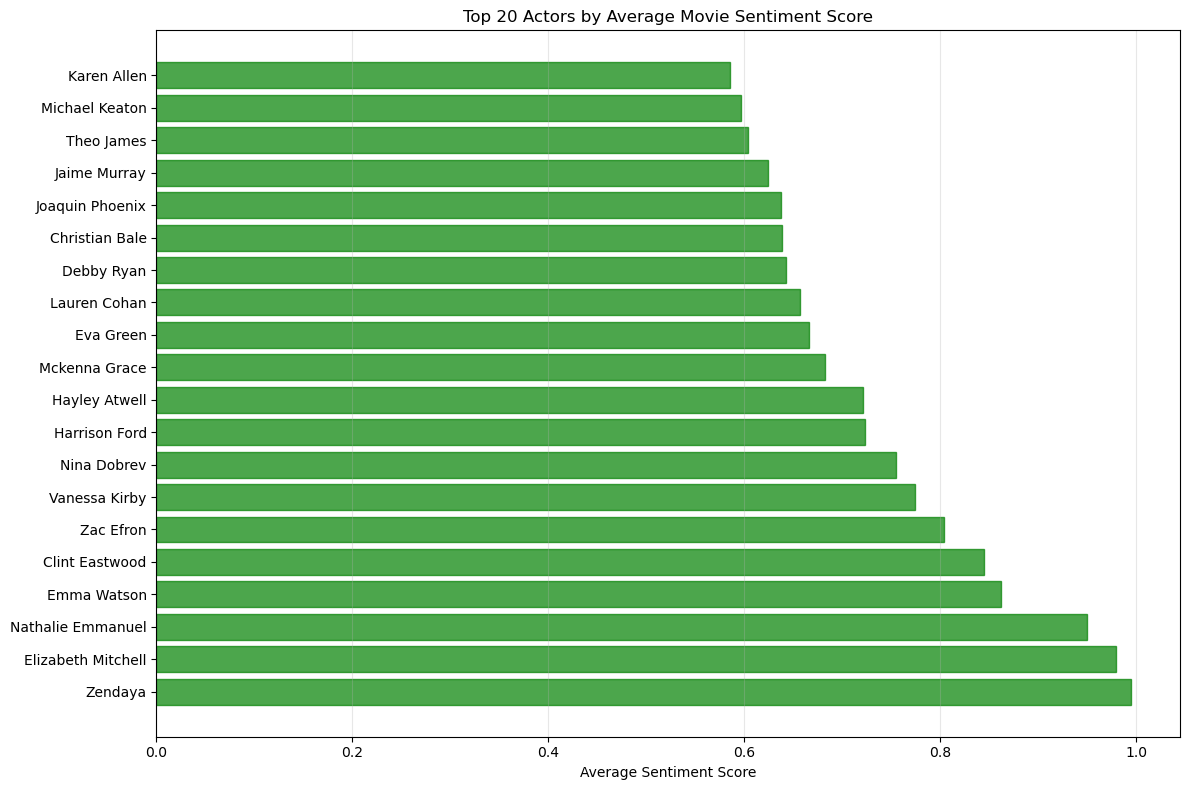

In [124]:
top_20_actors = actor_sentiment_stats.nlargest(20, 'avg_sentiment')

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_20_actors)), top_20_actors['avg_sentiment'])


colors = ['green' if x > 0 else 'red' for x in top_20_actors['avg_sentiment']]
for bar, color in zip(bars, colors):
    bar.set_color(color)
    bar.set_alpha(0.7)

plt.yticks(range(len(top_20_actors)), top_20_actors['name'])
plt.xlabel('Average Sentiment Score')
plt.title('Top 20 Actors by Average Movie Sentiment Score')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

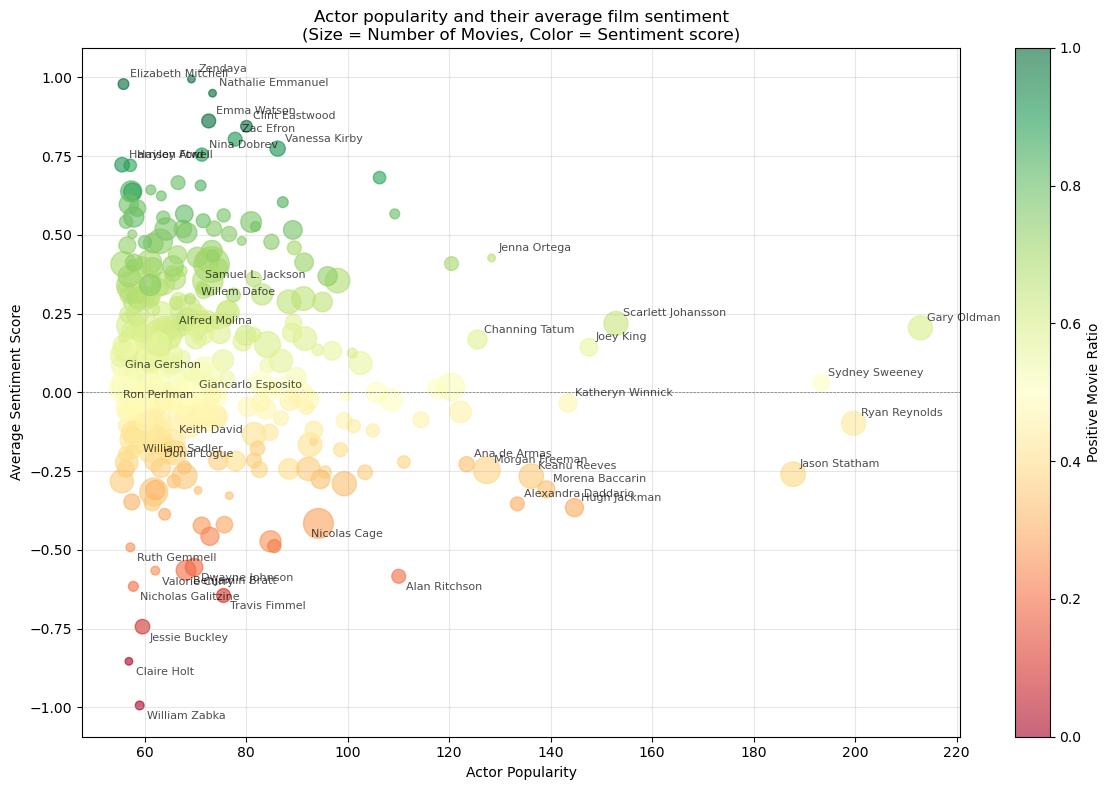


Spearman correlation between popularity and average sentiment: -0.098
P-value: 0.0668


In [125]:
from scipy import stats

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    actor_sentiment_stats['popularity'],
    actor_sentiment_stats['avg_sentiment'],
    s=actor_sentiment_stats['num_movies'] * 10,
    alpha=0.6,
    c=actor_sentiment_stats['positive_ratio'],
    cmap='RdYlGn'
)

plt.xlabel('Actor Popularity')
plt.ylabel('Average Sentiment Score')
plt.title('Actor popularity and their average film sentiment\n(Size = Number of Movies, Color = Sentiment score)')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
plt.grid(True, alpha=0.3)


cbar = plt.colorbar(scatter)
cbar.set_label('Positive Movie Ratio')

top_popular = actor_sentiment_stats.nlargest(15, 'popularity')
for _, actor in top_popular.iterrows():
    plt.annotate(
        actor['name'],
        (actor['popularity'], actor['avg_sentiment']),
        fontsize=8,
        alpha=0.7,
        xytext=(5, 5),
        textcoords='offset points'
    )

top_sentiment = actor_sentiment_stats.nlargest(10, 'avg_sentiment')
for _, actor in top_sentiment.iterrows():
    if actor['name'] not in top_popular['name'].values:
        plt.annotate(
            actor['name'],
            (actor['popularity'], actor['avg_sentiment']),
            fontsize=8,
            alpha=0.7,
            xytext=(5, 5),
            textcoords='offset points'
        )

# Annotate actors with lowest sentiment scores
bottom_sentiment = actor_sentiment_stats.nsmallest(10, 'avg_sentiment')
for _, actor in bottom_sentiment.iterrows():
    if actor['name'] not in top_popular['name'].values:
        plt.annotate(
            actor['name'],
            (actor['popularity'], actor['avg_sentiment']),
            fontsize=8,
            alpha=0.7,
            xytext=(5, -10),
            textcoords='offset points'
        )


most_movies = actor_sentiment_stats.nlargest(10, 'num_movies')
for _, actor in most_movies.iterrows():
    already_labeled = (actor['name'] in top_popular['name'].values or
                       actor['name'] in top_sentiment['name'].values or
                       actor['name'] in bottom_sentiment['name'].values)
    if not already_labeled:
        plt.annotate(
            actor['name'],
            (actor['popularity'], actor['avg_sentiment']),
            fontsize=8,
            alpha=0.7,
            xytext=(-5, -10),
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig('actor_popularity_and_the_average_sentiment_score_of_their_films.png', dpi=300, bbox_inches='tight')
plt.show()


spearman_corr, p_value = stats.spearmanr(actor_sentiment_stats['popularity'], actor_sentiment_stats['avg_sentiment'])
print(f"\nSpearman correlation between popularity and average sentiment: {spearman_corr:.3f}")
print(f"P-value: {p_value:.4f}")

In [126]:
spearman_corr, p_value = stats.spearmanr(all_actor_sentiment_stats['popularity'], all_actor_sentiment_stats['avg_sentiment'])
print(f"\nSpearman correlation between popularity and average sentiment: {spearman_corr:.3f}")
print(f"P-value: {p_value:.4f}")


Spearman correlation between popularity and average sentiment: -0.098
P-value: 0.0668
